In [110]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


# Exploratory Data Analysis

In [111]:

df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
print("Shape:", df.shape)
df.head()


Shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [112]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df = df.drop(columns=['id'])
column_list = df.columns.tolist()
print(column_list)


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [113]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and col != 'Churn']
print(binary_cols)
print(df[binary_cols].dtypes)
for col in binary_cols:
    print(col, df[col].unique())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
gender              object
SeniorCitizen        int64
Partner             object
Dependents          object
PhoneService        object
PaperlessBilling    object
dtype: object
gender ['Male' 'Female']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['Yes' 'No']
PhoneService ['Yes' 'No']
PaperlessBilling ['Yes' 'No']


In [114]:
binary_map = {
    'Yes':1,
    'No':0,
    'Male':1,
    'Female':0
}

for col in binary_cols:
    df[col] = df[col].replace(binary_map)

df[binary_cols].head()

/tmp/ipykernel_55/3866571393.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(binary_map)


,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling
0,1,0,1,1,1,1
1,1,0,1,1,1,0
2,1,0,1,0,1,1
3,0,0,0,0,1,1
4,0,0,0,0,1,1


In [115]:
for col in binary_cols:
    print("\n", col)
    print(pd.crosstab(df[col], df['Churn'], normalize='index'))


 gender
Churn          0         1
gender                    
0       0.771964  0.228036
1       0.777652  0.222348

 SeniorCitizen
Churn                 0         1
SeniorCitizen                    
0              0.810226  0.189774
1              0.499683  0.500317

 Partner
Churn           0         1
Partner                    
0        0.675379  0.324621
1        0.866204  0.133796

 Dependents
Churn              0         1
Dependents                    
0           0.708646  0.291354
1           0.927204  0.072796

 PhoneService
Churn               0        1
PhoneService                  
0             0.83185  0.16815
1             0.77108  0.22892

 PaperlessBilling
Churn                    0         1
PaperlessBilling                    
0                 0.925394  0.074606
1                 0.680613  0.319387


In [116]:
def churn_rate_by_feature(col):
    table = pd.crosstab(df[col], df['Churn'], normalize='index')
    print("\n", col)
    print(table)

for col in ['Contract','InternetService','PaymentMethod']:
    churn_rate_by_feature(col)


 Contract
Churn                  0         1
Contract                          
Month-to-month  0.579457  0.420543
One year        0.942372  0.057628
Two year        0.990018  0.009982

 InternetService
Churn                   0         1
InternetService                    
DSL              0.896936  0.103064
Fiber optic      0.584634  0.415366
No               0.985689  0.014311

 PaymentMethod
Churn                             0         1
PaymentMethod                                
Bank transfer (automatic)  0.922907  0.077093
Credit card (automatic)    0.930668  0.069332
Electronic check           0.510948  0.489052
Mailed check               0.920303  0.079697


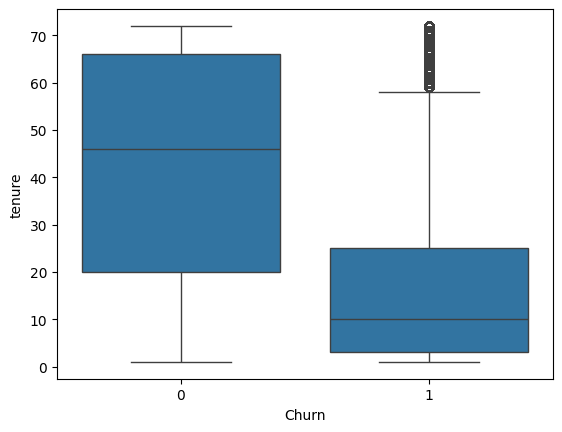

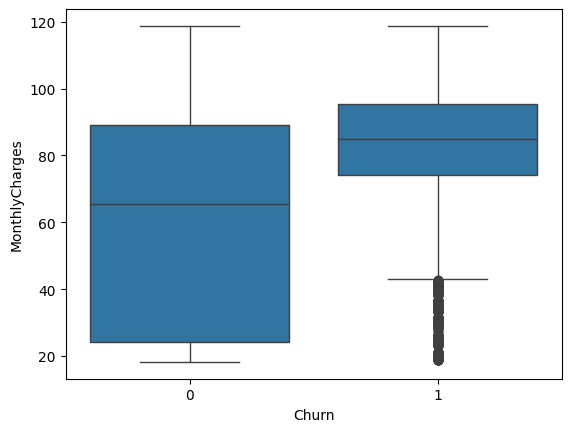

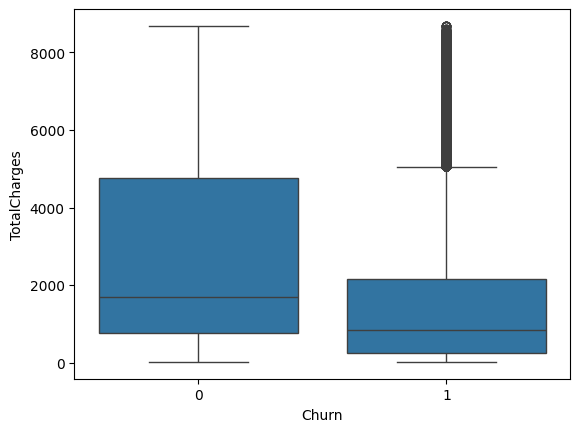

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.show()

In [118]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,1,29,1,No,DSL,Yes,No,Yes,Yes,No,No,One year,1,Mailed check,60.10,1653.85,0
1,1,0,1,1,58,1,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,0,Credit card (automatic),69.50,3778.20,0
2,1,0,1,0,58,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,1,Electronic check,100.40,5841.35,0
3,0,0,0,0,1,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,69.70,70.70,1
4,0,0,0,0,1,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.45,70.45,1


In [119]:
df_charges = df[['tenure', 'TotalCharges', 'MonthlyCharges', 'Churn']]
df_charges.head(50)

,tenure,TotalCharges,MonthlyCharges,Churn
0,29,1653.85,60.10,0
1,58,3778.20,69.50,0
2,58,5841.35,100.40,0
3,1,70.70,69.70,1
4,1,70.45,70.45,1
5,1,20.20,20.20,0
6,24,533.60,20.40,0
7,72,6827.50,92.00,0
8,1,79.55,79.55,1
9,55,4738.30,100.05,0


In [120]:
df_charges[df_charges['Churn'] == "Yes"].head(50)

,tenure,TotalCharges,MonthlyCharges,Churn


In [121]:
pd.crosstab(
    [df['Contract'], df['InternetService']],
    df['Churn'],
    normalize='index'
)


Churn                                  0         1
Contract       InternetService                    
Month-to-month DSL              0.774276  0.225724
               Fiber optic      0.449907  0.550093
               No               0.945031  0.054969
One year       DSL              0.977980  0.022020
               Fiber optic      0.867262  0.132738
               No               0.989084  0.010916
Two year       DSL              0.995965  0.004035
               Fiber optic      0.964564  0.035436
               No               0.997915  0.002085

In [122]:
pd.crosstab(
    [df['Contract'], df['PaymentMethod']],
    df['Churn'],
    normalize='index'
)

Churn                                            0         1
Contract       PaymentMethod                                
Month-to-month Bank transfer (automatic)  0.759701  0.240299
               Credit card (automatic)    0.766026  0.233974
               Electronic check           0.443202  0.556798
               Mailed check               0.826138  0.173862
One year       Bank transfer (automatic)  0.954352  0.045648
               Credit card (automatic)    0.958142  0.041858
               Electronic check           0.853875  0.146125
               Mailed check               0.985475  0.014525
Two year       Bank transfer (automatic)  0.990385  0.009615
               Credit card (automatic)    0.991366  0.008634
               Electronic check           0.946401  0.053599
               Mailed check               0.997997  0.002003

In [123]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1yr','1-2yr','2-4yr','4-6yr']
)
pd.crosstab(
    [df['tenure_group'], df['Contract']],
    df['Churn'],
    normalize='index'
)

Churn                               0         1
tenure_group Contract                          
0-1yr        Month-to-month  0.481515  0.518485
             One year        0.969228  0.030772
             Two year        0.995034  0.004966
1-2yr        Month-to-month  0.639835  0.360165
             One year        0.978505  0.021495
             Two year        0.998389  0.001611
2-4yr        Month-to-month  0.677884  0.322116
             One year        0.960119  0.039881
             Two year        0.996603  0.003397
4-6yr        Month-to-month  0.747375  0.252625
             One year        0.917631  0.082369
             Two year        0.988470  0.011530

In [124]:
df['HasFamily'] = ((df['Partner'] == 1) | (df['Dependents'] == 1)).astype(int)
services = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

df['ServiceCount'] = df[services].apply(lambda x: (x=='Yes').sum(), axis=1)

df['ChargeRatio'] = df['TotalCharges'] / (df['tenure'] + 1)

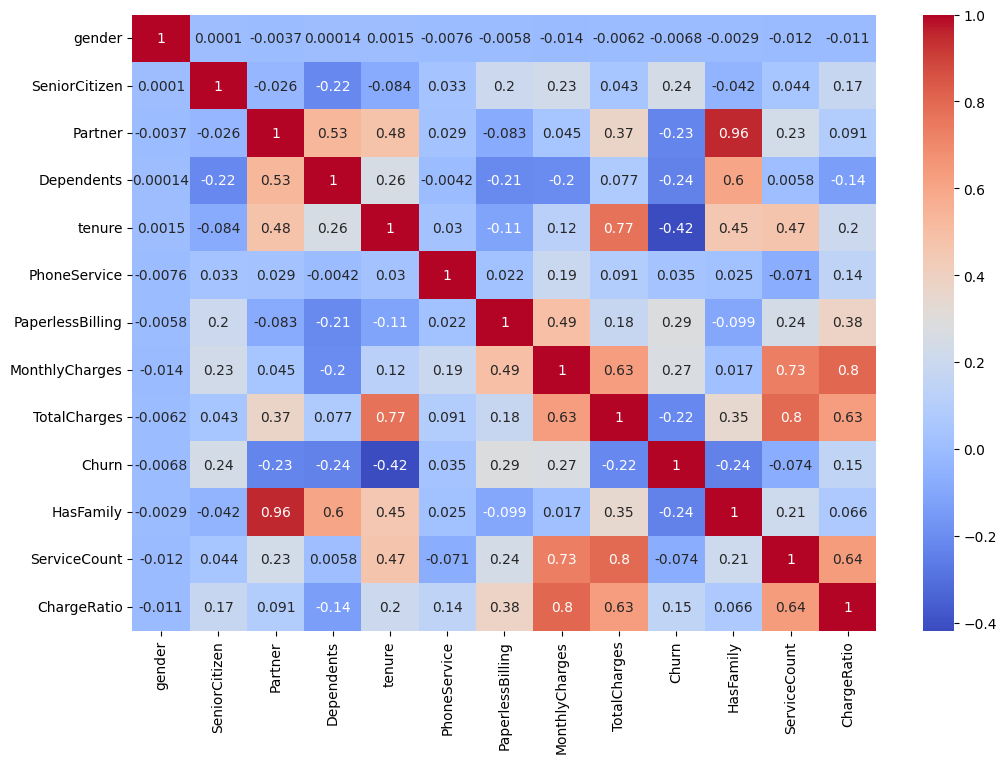

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# MODEL DEVELOPMENT

In [126]:
# Separate target
y = df['Churn']
X = df.drop(columns=['Churn'])

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)
print(X.shape)

(594194, 36)


In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [108]:
print(y_test.head(10))
print(y_train.head(10))

493665    1.0
128315    0.0
430597    0.0
341073    1.0
513192    0.0
135306    0.0
83358     0.0
263933    0.0
118151    0.0
137727    0.0
Name: Churn, dtype: float32
6165      0.0
565551    0.0
85537     0.0
137025    0.0
436494    0.0
129974    0.0
231339    1.0
579728    1.0
380494    0.0
72351     0.0
Name: Churn, dtype: float32


In [107]:
# Force correct, clean target – run this once right after splitting
y_train = y_train.astype('float32')
y_test  = y_test.astype('float32')
if y_train.hasnans or y_test.hasnans:
    print("NaN count in y_train:", y_train.isna().sum())
    print("NaN count in y_test :", y_test.isna().sum())
    # Optional: drop bad rows (but better to find root cause)
    # valid = y_train.notna() & X_train.index.isin(y_train.index)
    # X_train = X_train[valid]
    # y_train = y_train[valid]
    raise ValueError("Target contains NaN – fix before proceeding")

# Safety net: fail loudly if something is wrong
if y_train.isna().any() or y_test.isna().any():
    raise ValueError("NaN detected in target after cleaning – check earlier cells!")

print("After safety conversion:")
print(y_train.value_counts(dropna=False))
print(y_test.value_counts(dropna=False))

After safety conversion:
Churn
0.0    368301
1.0    107054
Name: count, dtype: int64
Churn
0.0    92076
1.0    26763
Name: count, dtype: int64


# Benchmark - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

In [ ]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": log_model.coef_[0]
})

coefficients.sort_values(by="Importance", ascending=False).head(10)

# Benchmark - Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
y_prob = tree_model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

# Benchmark | Random Forest | ROC-AUC: 91.246

In [133]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9124696379597829
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.70      0.64      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.85      0.86      0.85    118839



In [ ]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importances.sort_values(by="Importance", ascending=False).head(15)

In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# -----------------------------
# 1️⃣ Prepare Data
# -----------------------------
# Convert Yes/No to 1/0
y_train = y_train.map({'No':0,'Yes':1})
y_test = y_test.map({'No':0,'Yes':1})
# Convert pandas to torch tensors
X_train_tensor = torch.from_numpy(X_train.values.astype(np.float32))
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor  = torch.from_numpy(X_test.values.astype(np.float32))
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# Create DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [77]:
print("Type of y_train:", type(y_train))
print("Shape of y_train:", y_train.shape if hasattr(y_train, 'shape') else "no shape")

# Show first 10 values exactly as they are
print("\nFirst 10 raw values in y_train:")
print(y_train.head(10))

print("\nColumn names if it's a DataFrame:")
if isinstance(y_train, pd.DataFrame):
    print(y_train.columns.tolist())

Type of y_train: <class 'pandas.core.series.Series'>
Shape of y_train: (475355,)

First 10 raw values in y_train:
6165     NaN
565551   NaN
85537    NaN
137025   NaN
436494   NaN
129974   NaN
231339   NaN
579728   NaN
380494   NaN
72351    NaN
Name: Churn, dtype: float64

Column names if it's a DataFrame:


In [76]:
print("=== TARGET DIAGNOSTICS ===")
print("y_train dtype:", y_train.dtype)
print("y_train unique values:\n", y_train.value_counts(dropna=False))
print("y_train has NaN:", y_train.isna().any())
print("Number of NaN in y_train:", y_train.isna().sum())

print("\ny_test unique values:\n", y_test.value_counts(dropna=False))
print("y_test has NaN:", y_test.isna().any())
print("Number of NaN in y_test:", y_test.isna().sum())

# If you still have the original string version (before mapping), check it:
# print(y_train_original.value_counts(dropna=False))

=== TARGET DIAGNOSTICS ===
y_train dtype: float64
y_train unique values:
 Churn
NaN    475355
Name: count, dtype: int64
y_train has NaN: True
Number of NaN in y_train: 475355

y_test unique values:
 Churn
NaN    118839
Name: count, dtype: int64
y_test has NaN: True
Number of NaN in y_test: 118839


# Neural Network | ROC-AUC 91.32

In [109]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# ────────────────────────────────────────────────
# 1. Assume your data is already split
#    X_train, X_test, y_train, y_test are pandas objects
# ────────────────────────────────────────────────

# A. Make sure target is numeric (0/1)
if y_train.dtype == 'object':
    y_train = y_train.map({'No': 0, 'Yes': 1}).astype(np.float32)
if y_test.dtype == 'object':
    y_test = y_test.map({'No': 0, 'Yes': 1}).astype(np.float32)

# B. Identify columns that should be scaled (continuous features)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# Add any other continuous columns you have

# C. Scale numeric features
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# D. Force ALL columns to float32 — this fixes bool → object dtype problem
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

# Quick safety prints (you can comment out later)
print("X_train dtypes after conversion:\n", X_train.dtypes.value_counts())
print("X_train.values dtype:", X_train.values.dtype)          # should be float32
print("Any NaN in X_train?", np.isnan(X_train.values).any())
print("Any inf in X_train?", np.isinf(X_train.values).any())

# ────────────────────────────────────────────────
# 2. Create PyTorch tensors
# ────────────────────────────────────────────────

X_train_tensor = torch.from_numpy(X_train.to_numpy()).float()
y_train_tensor = torch.from_numpy(y_train.to_numpy()).float().view(-1, 1)

X_test_tensor  = torch.from_numpy(X_test.to_numpy()).float()
y_test_tensor  = torch.from_numpy(y_test.to_numpy()).float().view(-1, 1)

# ────────────────────────────────────────────────
# 3. DataLoaders
# ────────────────────────────────────────────────

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

# ────────────────────────────────────────────────
# 4. Model (NO final sigmoid — using BCEWithLogitsLoss)
# ────────────────────────────────────────────────

class ChurnModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.25),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1)          # ← raw logits
        )
    
    def forward(self, x):
        return self.net(x)


model = ChurnModel(input_size=X_train.shape[1])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ────────────────────────────────────────────────
# 5. Loss + Optimizer
# ────────────────────────────────────────────────

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

# ────────────────────────────────────────────────
# 6. Training loop with NaN protection
# ────────────────────────────────────────────────

epochs = 80
best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    batch_count = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"NaN/Inf detected at epoch {epoch+1} — stopping")
            break
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=4.0)
        optimizer.step()
        
        total_loss += loss.item()
        batch_count += 1
    
    if batch_count == 0:
        print("Training collapsed — no valid batches")
        break
    
    avg_loss = total_loss / batch_count
    print(f"Epoch {epoch+1:2d}/{epochs}   loss: {avg_loss:.6f}")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "best_churn_model.pt")

print("\nTraining finished.\n")

# ────────────────────────────────────────────────
# 7. Evaluation
# ────────────────────────────────────────────────

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(yb.numpy())

probs = np.concatenate(all_probs).ravel()
labels = np.concatenate(all_labels).ravel()

preds = (probs >= 0.5).astype(int)

print("Accuracy:      {:.4f}".format(accuracy_score(labels, preds)))
print("ROC AUC:       {:.4f}".format(roc_auc_score(labels, probs)))
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=["Stay", "Churn"]))

print("\nConfusion Matrix:")
print(confusion_matrix(labels, preds))

X_train dtypes after conversion:
 float32    36
Name: count, dtype: int64
X_train.values dtype: float32
Any NaN in X_train? False
Any inf in X_train? False
Epoch  1/80   loss: 0.331264
Epoch  2/80   loss: 0.315922
Epoch  3/80   loss: 0.314432
Epoch  4/80   loss: 0.313259
Epoch  5/80   loss: 0.312445
Epoch  6/80   loss: 0.312138
Epoch  7/80   loss: 0.312157
Epoch  8/80   loss: 0.311709
Epoch  9/80   loss: 0.311413
Epoch 10/80   loss: 0.310903
Epoch 11/80   loss: 0.310845
Epoch 12/80   loss: 0.310997
Epoch 13/80   loss: 0.310722
Epoch 14/80   loss: 0.310622
Epoch 15/80   loss: 0.310202
Epoch 16/80   loss: 0.310143
Epoch 17/80   loss: 0.309832
Epoch 18/80   loss: 0.309947
Epoch 19/80   loss: 0.309738
Epoch 20/80   loss: 0.309962
Epoch 21/80   loss: 0.310187
Epoch 22/80   loss: 0.309913
Epoch 23/80   loss: 0.309818
Epoch 24/80   loss: 0.310038
Epoch 25/80   loss: 0.309659
Epoch 26/80   loss: 0.309704
Epoch 27/80   loss: 0.309681
Epoch 28/80   loss: 0.309721
Epoch 29/80   loss: 0.309634
Epo

# XGB-BOOST | ROC-AUC: 91.645

In [129]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
prob = xgb.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))
print(classification_report(y_test, pred))

Accuracy: 0.8608790043672532
ROC-AUC: 0.9164549607777924
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.64      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839



# LIGHT GB | ROC-AUC: 91.658

In [131]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

pred = lgbm.predict(X_test)
prob = lgbm.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))
print(classification_report(y_test, pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033257 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 907
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Accuracy: 0.8609210780972576
ROC-AUC: 0.916585309406599
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.64      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.8

# CAT BOOST | ROC-AUC: 91.592

In [132]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=False
)

cat.fit(X_train, y_train)

pred = cat.predict(X_test)
prob = cat.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))
print(classification_report(y_test, pred))

Accuracy: 0.860424608083205
ROC-AUC: 0.915928969694853
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     92076
           1       0.71      0.64      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

